# Combinations with Lensing

In this notebook, we will look at the Lensing likelihood and look at the effect that lensing has on CMB constraints.

In [ ]:
import jax
from jax import numpy as jnp
from jax import scipy as jsc
from jax import random as jrd

import numpy as np
import matplotlib.pyplot as plt

import camb

import sys
sys.path.insert(0, "../")

import mflike_jax
import mflike_jax.util

import pprint

try:
    from tqdm.notebook import tqdm
except:
    tqdm = lambda x: x

In [ ]:
# Please see notebook 3 for installation instructions on Cosmopower.
import sys

sys.path.insert(0, "cosmopower")

import cosmopower as cp
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX

In [ ]:
parser = cp.YAMLParser("jense_2024_emulators/jense_2023_cmb_camb_lcdm.yaml", root_dir="jense_2024_emulators")

emulators = mflike_jax.util.emulators_to_jax(parser, desired=["tt", "te", "ee", "pp"])

T_CMB = 2.72548e6

cmb_tt = emulators["tt"]
cmb_te = emulators["te"]
cmb_ee = emulators["ee"]
cmb_pp = emulators["pp"]

In [ ]:
lensing_like = mflike_jax.Lensing_jax("so_example_lensing.yaml")

In [5]:
print(cmb_pp.parameters)
theta = jnp.array([0.022, 0.117, 3.044, 0.96, 0.67])

dlpp = cmb_pp.predict(theta)

chi2 = lensing_like.chisquare(dlpp)

print(f"chi square = {chi2:.3f}")

['ombh2', 'omch2', 'logA', 'ns', 'h']
chi square = 64.425


In [6]:
# The lensing likelihood needs to be corrected for the cosmology.
# This has been implemented similar to the primary CMB foregrounds.
lensing_corrections = mflike_jax.LensingCorrections("so_example_lensing_corrections.yaml")

In [7]:
theta_cmb = jnp.array([0.022, 0.117, 3.044, 0.06, 0.96, 0.67])

dltt = cmb_tt.predict(theta_cmb) * (T_CMB ** 2.)
dlte = cmb_te.predict(theta_cmb) * (T_CMB ** 2.)
dlee = cmb_ee.predict(theta_cmb) * (T_CMB ** 2.)
# Cosmopower-jax doesn't like BB emulators :(
# We'll just take zero BB modes for now.
dlbb = np.zeros_like(dltt)

corr = lensing_corrections.get_corrections(dltt, dlte, dlee, dlbb, dlpp)

chi2 = lensing_like.chisquare(dlpp, corr)
print(f"chi square = {chi2:.3f}")

chi square = 74.177


In [8]:
cmb_like = mflike_jax.MFLike_jax("../act_dr6.yaml")
fg_model = mflike_jax.BandpowerForegrounds("../act_dr6_foregrounds.yaml", cmb_like)

Assuming data rows are in the correct order as it was before version 1.0.


In [9]:
# This is all a copy of stuff from the previous notebooks.
priors = {
    "calG_all": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.003),

    "cal_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.013),
    "cal_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0016),
    "cal_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0020),
    "cal_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0018),
    "cal_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0024),

    "bandint_shift_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=3.6),
    "bandint_shift_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.0),
    "bandint_shift_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.3),
    "bandint_shift_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.2),
    "bandint_shift_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.1),

    "a_gtt": lambda x: jsc.stats.norm.logpdf(x, loc=7.95, scale=0.32),
    "a_gte": lambda x: jsc.stats.norm.logpdf(x, loc=0.432, scale=0.03),
    "a_gee": lambda x: jsc.stats.norm.logpdf(x, loc=0.1681, scale=0.017),

    "tau": lambda x: jsc.stats.norm.logpdf(x, loc=5.44e-2, scale=7e-3),
}

prior_sigmas = {
    "calG_all": 0.003,
    "cal_dr6_pa4_f220": 0.013,
    "cal_dr6_pa5_f090": 0.0016,
    "cal_dr6_pa5_f150": 0.0020,
    "cal_dr6_pa6_f090": 0.0018,
    "cal_dr6_pa5_f150": 0.0024,
    "bandint_shift_pa4_f220": 3.6,
    "bandint_shift_pa5_f090": 1.0,
    "bandint_shift_pa5_f150": 1.3,
    "bandint_shift_pa6_f090": 1.2,
    "bandint_shift_pa6_f150": 1.1,
    "a_gtt": 0.32,
    "a_gte": 0.03,
    "a_gee": 0.017
}

parameters = cmb_tt.parameters + cmb_like.parameters + fg_model.parameters

idx_cmb = jnp.array([parameters.index(p) for p in cmb_tt.parameters])
idx_pp = jnp.array([parameters.index(p) for p in cmb_pp.parameters])
idx_like_cmb = jnp.array([parameters.index(p) for p in cmb_like.parameters])
idx_fg = jnp.array([parameters.index(p) for p in fg_model.parameters])

@jax.jit
def cmb_spectra(theta):
    spec_tt = jnp.concatenate([ jnp.array([0.,0.]), cmb_tt.predict(theta) * (T_CMB ** 2.) ])
    spec_te = jnp.concatenate([ jnp.array([0.,0.]), cmb_te.predict(theta) * (T_CMB ** 2.) ])
    spec_ee = jnp.concatenate([ jnp.array([0.,0.]), cmb_ee.predict(theta) * (T_CMB ** 2.) ])

    return spec_tt, spec_te, spec_ee

@jax.jit
def logpost_cmb_plus_lensing(theta):
    logprior = jnp.sum(jnp.array([
        priors[p](theta[parameters.index(p)]) for p in priors
    ]))

    theta_cmb = theta[idx_cmb]
    theta_pp = theta[idx_pp]
    theta_like = theta[idx_like_cmb]
    theta_fg = theta[idx_fg]

    # Then we need a likelihood contribution.
    dltt, dlte, dlee = cmb_spectra(theta_cmb)
    foregrounds = fg_model.get_foreground_model(theta_fg)
    loglike_cmb = cmb_like.loglike(dltt, dlte, dlee, foregrounds, theta_like)

    dlbb = jnp.zeros_like(dlee)
    dlpp = cmb_pp.predict(theta_pp)
    corr = lensing_corrections.get_corrections(dltt, dlte, dlee, dlbb, dlpp)
    loglike_lensing = lensing_like.loglike(dlpp, corr)

    return logprior + loglike_cmb + loglike_lensing

@jax.jit
def logpost_cmb_only(theta):
    logprior = jnp.sum(jnp.array([
        priors[p](theta[parameters.index(p)]) for p in priors
    ]))

    theta_cmb = theta[idx_cmb]
    theta_like = theta[idx_like_cmb]
    theta_fg = theta[idx_fg]

    # Then we need a likelihood contribution.
    dltt, dlte, dlee = cmb_spectra(theta_cmb)
    foregrounds = fg_model.get_foreground_model(theta_fg)
    loglike_cmb = cmb_like.loglike(dltt, dlte, dlee, foregrounds, theta_like)

    return logprior + loglike_cmb

parameter_values = {
    "ombh2": 0.022,
    "omch2": 0.117,
    "h": 0.67,
    "logA": 3.05,
    "ns": 0.97,
    "tau": 0.06,

    "a_tSZ": 3.4,
    "alpha_tSZ": -0.5,
    "a_kSZ": 1.5,
    "a_c": 3.7,
    "a_p": 7.7,
    "beta_cib": 1.9,
    "xi": 0.1,
    "a_s": 2.8,
    "beta_s": -2.8,
    "a_pste": -0.025,
    "a_psee": 0.02,

    "a_gtt": 7.95,
    "a_gte": 0.423,
    "a_gee": 0.1681,

    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "alpha_s": 1.0,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,
    "alpha_p": 1.0,
    "alpha_c": 0.8,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 1.0,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 1.0,
    "calE_dr6_pa5_f150": 1.0,
    "calE_dr6_pa6_f090": 1.0,
    "calE_dr6_pa6_f150": 1.0,

    "bandint_shift_dr6_pa4_f220": 0.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": 0.0,
    "bandint_shift_dr6_pa6_f090": 0.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

def model_logpost(param_names, logpost):
    fit_idx = jnp.array([ parameters.index(p) for p in param_names ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    def restricted_logpost(theta_x):
        theta = theta_default.at[fit_idx].set(theta_x)
        return logpost(theta)

    return jax.jit(restricted_logpost)

In [10]:
parameters_baseline = [
    "ombh2", "omch2", "h", "logA", "tau", "ns",
    "a_tSZ", "a_kSZ", "alpha_tSZ", "xi", "a_c", "a_p", "beta_cib", "a_s", "beta_s",
    "a_gtt", "a_gte", "a_gee", "a_pste", "a_psee",
    "calG_all", "cal_dr6_pa4_f220", "cal_dr6_pa5_f090", "cal_dr6_pa5_f150", "cal_dr6_pa6_f090", "cal_dr6_pa6_f150",
    "calE_dr6_pa5_f090", "calE_dr6_pa5_f150", "calE_dr6_pa6_f090", "calE_dr6_pa6_f150",
    "bandint_shift_dr6_pa4_f220", "bandint_shift_dr6_pa5_f090", "bandint_shift_dr6_pa5_f150", "bandint_shift_dr6_pa6_f090", "bandint_shift_dr6_pa6_f150",
]

logp_cmb = model_logpost(parameters_baseline, logpost_cmb_only)
logp_cmb_lensing = model_logpost(parameters_baseline, logpost_cmb_plus_lensing)

theta_baseline = jnp.array([ parameter_values[p] for p in parameters_baseline ])

print(f"Log-post CMB+Lensing = {logp_cmb_lensing(theta_baseline):.3f}")
print(f"Log-post CMB-only    = {logp_cmb(theta_baseline):.3f}")

Log-post CMB+Lensing = -2654.235
Log-post CMB-only    = -2243.512


# Visualizing Constraining power across our dataset

Which one of our primary CMB cross-spectra has the tightest constraints on $\Omega_m$? How about in combination with lensing? Which detector (`pa4_f220`, `pa5_f090`, `pa5_f150`, `pa6_f090`, `pa6_f150`)?

Here, we use auto-differentiation to quickly compute the Jacobian across different subsets of the data.

In [11]:
# First, we compute the Fisher matrix for our full dataset.
def cmb_model(theta):
    fit_idx = jnp.array([ parameters.index(p) for p in parameters_baseline ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    theta = theta_default.at[fit_idx].set(theta)
    
    theta_cmb = theta[idx_cmb]
    theta_like = theta[idx_like_cmb]
    theta_fg = theta[idx_fg]

    dltt, dlte, dlee = cmb_spectra(theta_cmb)
    foregrounds = fg_model.get_foreground_model(theta_fg)
    return cmb_like.get_model(dltt, dlte, dlee, foregrounds, theta_like)

def lensing_model(theta):
    fit_idx = jnp.array([ parameters.index(p) for p in parameters_baseline ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    theta = theta_default.at[fit_idx].set(theta)

    theta_cmb = theta[idx_cmb]
    theta_pp = theta[idx_pp]

    dltt, dlte, dlee = cmb_spectra(theta_cmb)
    dlpp = cmb_pp.predict(theta_pp)
    
    corr = lensing_corrections.get_corrections(dltt, dlte, dlee, dlbb, dlpp)
    return lensing_like.get_model(dlpp, corr)

# CMB jacobian
jac_cmb = jax.jit(jax.jacfwd(cmb_model))
# Lensing jacobian
jac_lensing = jax.jit(jax.jacfwd(lensing_model))

In [12]:
F_priors = np.diag([ 1. / prior_sigmas[p]**2 if p in prior_sigmas else 0.0 for p in parameters_baseline ])

J_cmb = jac_cmb(theta_baseline)
F_cmb = J_cmb.T @ cmb_like.inv_cov @ J_cmb

J_lensing = jac_lensing(theta_baseline)
F_lensing = J_lensing.T @ lensing_like.inv_cov @ J_lensing

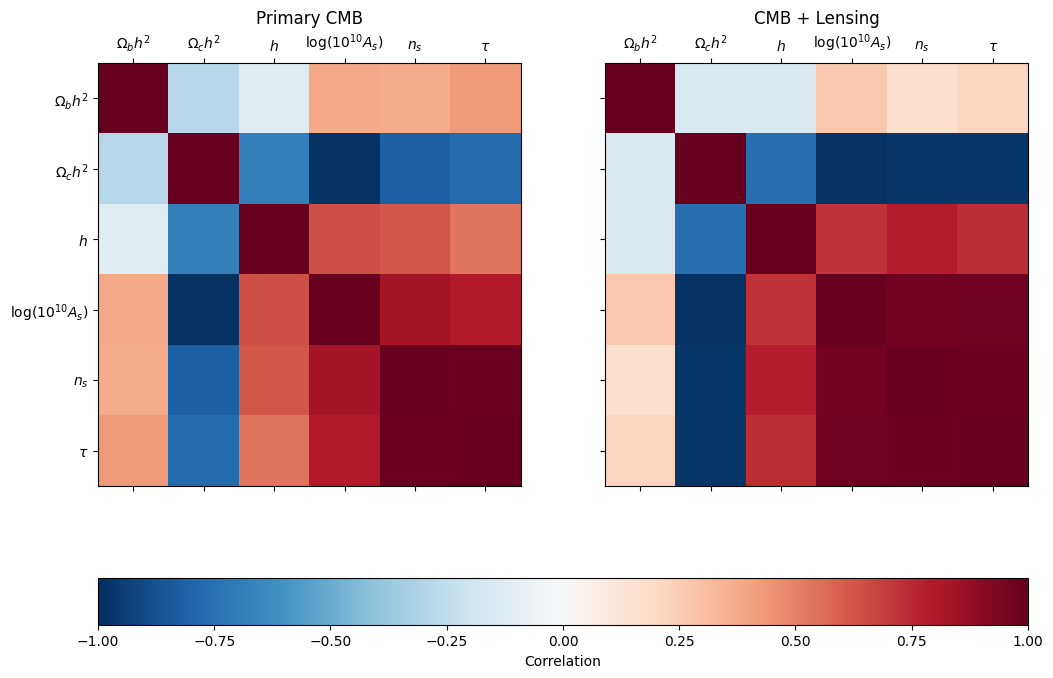

In [13]:
cov_cmb = np.linalg.inv(F_priors + F_cmb)
err_cmb = np.sqrt(np.diag(cov_cmb))

corr_cmb = cov_cmb / (err_cmb[None,:] * err_cmb[:,None])

cov_all = np.linalg.inv(F_priors + F_cmb + F_lensing)
err_all = np.sqrt(np.diag(cov_all))

corr_all = cov_all / (err_all[None,:] * err_all[:,None])

labels = {
    "ombh2": r"\Omega_b h^2",
    "omch2": r"\Omega_c h^2",
    "h": r"h",
    "logA": r"\log(10^{10}A_s)",
    "ns": r"n_s",
    "tau": r"\tau",
}

idx = np.array([ parameters.index(p) for p in labels ])

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

ax = axes[0]
ax.set_title("Primary CMB")
im = ax.matshow(corr_cmb[np.ix_(idx,idx)], vmin=-1., vmax=1., cmap="RdBu_r")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels([f"${labels[p]}$" for p in labels])
ax.set_yticklabels([f"${labels[p]}$" for p in labels])

ax = axes[1]
ax.set_title("CMB + Lensing")
im = ax.matshow(corr_all[np.ix_(idx,idx)], vmin=-1., vmax=1., cmap="RdBu_r")
fig.colorbar(im, ax=axes[:], orientation="horizontal", label="Correlation")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([f"${labels[p]}$" for p in labels]);

In [14]:
# Find the indices that do NOT contain any contributions from X.
experiment_cuts = {
    x : jnp.concatenate([
        m["ids"] if (m["exp1"] != x and m["exp2"] != x) else np.array([], dtype=int) for m in cmb_like.spec_meta
    ]) for x in cmb_like.experiments
}

fishers = {}

for x in experiment_cuts:
    idx = experiment_cuts[x]
    F_cmb = J_cmb[idx,:].T @ np.linalg.inv(cmb_like.covmat[np.ix_(idx,idx)]) @ J_cmb[idx,:]

    fishers[x] = F_cmb

/tmp/ipykernel_27863/3566457930.py:9: RuntimeWarning: invalid value encountered in sqrt
  errors[x] = np.sqrt(np.diag(np.linalg.pinv(F_priors + fishers[x])))
/tmp/ipykernel_27863/3566457930.py:10: RuntimeWarning: invalid value encountered in sqrt
  errors[x + "-lensing"] = np.sqrt(np.diag(np.linalg.pinv(F_priors + fishers[x] + F_lensing)))


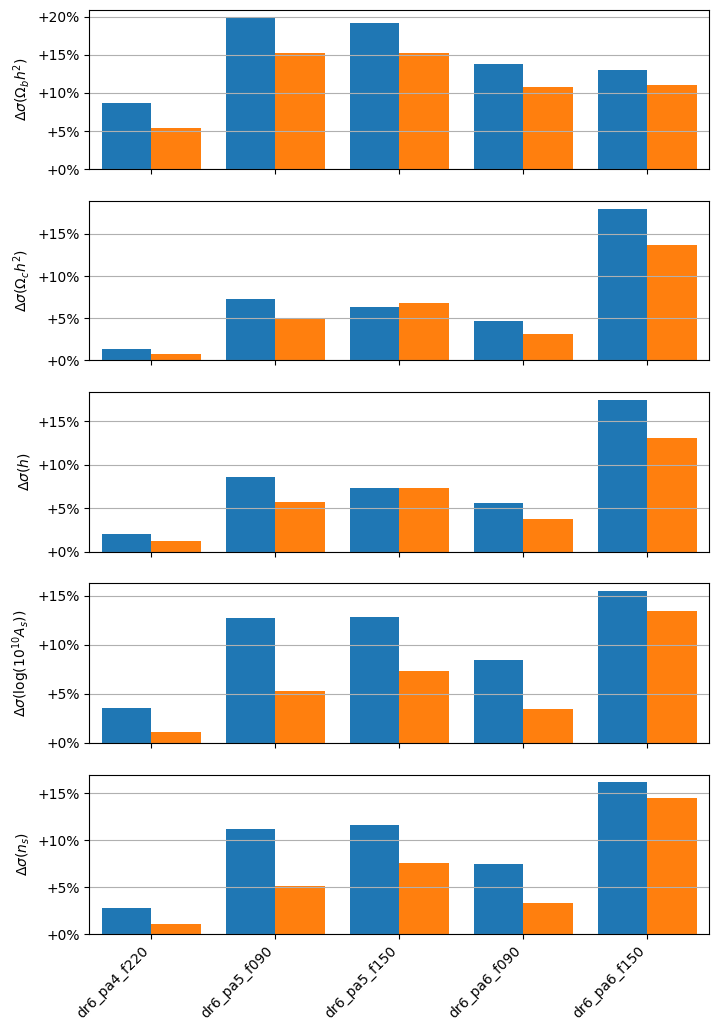

In [15]:
errors = {}
errors["cmb"] = np.sqrt(np.diag(cov_cmb))
errors["cmb-lensing"] = np.sqrt(np.diag(cov_all))

for x in fishers:
    # These fisher matrices are degenerate because we are leaving out an entire detector array
    # without culling any nuisances - we'll just take the pseudo-inverse here as an example.
    # A proper analysis would correct the likelihood.
    errors[x] = np.sqrt(np.diag(np.linalg.pinv(F_priors + fishers[x])))
    errors[x + "-lensing"] = np.sqrt(np.diag(np.linalg.pinv(F_priors + fishers[x] + F_lensing)))

labels = {
    "ombh2": r"\Omega_b h^2",
    "omch2": r"\Omega_c h^2",
    "h": r"h",
    "logA": r"\log(10^{10}A_s)",
    "ns": r"n_s",
}

# We now plot how much each error bar increases when we leave out each detector array
# in the primary CMB, both with and without lensing.
fig, axes = plt.subplots(len(labels), 1, figsize = (8, 12), sharex=True)

import matplotlib.ticker as ticker

for i, (j, p) in enumerate(zip(idx, labels)):
    y = np.array([ errors[x][j] / errors["cmb"][j] - 1. for x in cmb_like.experiments ])
    axes[i].bar(np.arange(2, len(errors), 2)-0.4, 100.*y, label="CMB")

    y = np.array([ errors[x+"-lensing"][j] / errors["cmb-lensing"][j] - 1. for x in cmb_like.experiments ])
    axes[i].bar(np.arange(2, len(errors), 2)+0.4, 100.*y, label="CMB+Lensing")

    axes[i].yaxis.set_major_formatter(ticker.FormatStrFormatter('%+0.0f%%'))
    axes[i].set_ylabel(f"$\\Delta\\sigma({labels[p]})$")
    axes[i].grid(True, axis="y")

axes[-1].set_xlim(1, len(errors)-1)
axes[-1].set_xticks(range(2, len(errors), 2))
axes[-1].set_xticklabels(list(errors.keys())[2::2], ha="right", rotation=45);